In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load Data
# ============================================================

data_dir = "./data"

EEG = np.load(f"{data_dir}/EEG_all_epochs.npy", allow_pickle=True)
EOG = np.load(f"{data_dir}/EOG_all_epochs.npy", allow_pickle=True)
EMG = np.load(f"{data_dir}/EMG_all_epochs.npy", allow_pickle=True)


# Denoising data after recording

In [ ]:
# prepare the data using the provided function
import sys
sys.path.append('./code/benchmark_networks')
from data_prepare import prepare_data

EEG = np.array(EEG.tolist(), dtype=np.float32)
EOG = np.array(EOG.tolist(), dtype=np.float32)
EMG = np.array(EMG.tolist(), dtype=np.float32)

print(f"Originele groottes — EEG: {len(EEG)}, EOG: {len(EOG)}, EMG: {len(EMG)}")

# Afkappen zodat EEG en noise even groot zijn
n_eog = min(len(EEG), len(EOG))
n_emg = min(len(EEG), len(EMG))

# EOG dataset: clean EEG + EOG artefact
noisy_eog_train, clean_eog_train, noisy_eog_val, clean_eog_val, noisy_eog_test, clean_eog_test, std_eog = \
    prepare_data(EEG_all=EEG[:n_eog], noise_all=EOG[:n_eog], combin_num=10, train_per=0.8, noise_type='EOG')

# EMG dataset: clean EEG + EMG artefact
noisy_emg_train, clean_emg_train, noisy_emg_val, clean_emg_val, noisy_emg_test, clean_emg_test, std_emg = \
    prepare_data(EEG_all=EEG[:n_emg], noise_all=EMG[:n_emg], combin_num=10, train_per=0.8, noise_type='EMG')

print("EOG — train:", noisy_eog_train.shape, "| val:", noisy_eog_val.shape, "| test:", noisy_eog_test.shape)
print("EMG — train:", noisy_emg_train.shape, "| val:", noisy_emg_val.shape, "| test:", noisy_emg_test.shape)

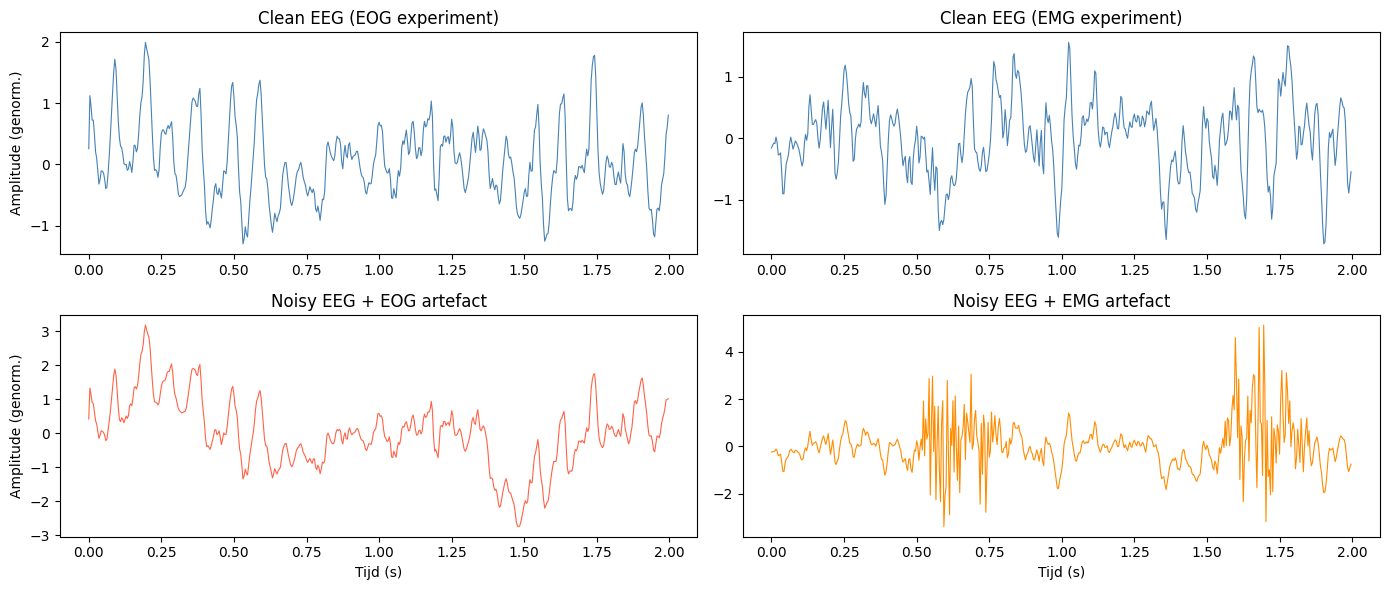

In [ ]:
# plot signals
fs = 256
t = np.arange(512) / fs

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

# EOG
axes[0, 0].plot(t, clean_eog_train[0], color="steelblue", linewidth=0.8)
axes[0, 0].set_title("Clean EEG (EOG experiment)")
axes[0, 0].set_ylabel("Amplitude (genorm.)")

axes[1, 0].plot(t, noisy_eog_train[0], color="tomato", linewidth=0.8)
axes[1, 0].set_title("Noisy EEG + EOG artefact")
axes[1, 0].set_ylabel("Amplitude (genorm.)")
axes[1, 0].set_xlabel("Tijd (s)")

# EMG
axes[0, 1].plot(t, clean_emg_train[0], color="steelblue", linewidth=0.8)
axes[0, 1].set_title("Clean EEG (EMG experiment)")

axes[1, 1].plot(t, noisy_emg_train[0], color="darkorange", linewidth=0.8)
axes[1, 1].set_title("Noisy EEG + EMG artefact")
axes[1, 1].set_xlabel("Tijd (s)")

plt.tight_layout()
plt.show()

## Code for evaluation


In [22]:
import numpy as np

# uses RRMSE and Pearson Correlation for evaluation
def evaluate(clean, denoised, naam=""):
    rrmse = np.sqrt(np.mean((clean - denoised) ** 2) / np.mean(clean ** 2))
    corr  = np.mean([np.corrcoef(clean[i], denoised[i])[0, 1] for i in range(len(clean))])
    print(f"{naam} — RRMSE: {rrmse:.4f} | Correlatie: {corr:.4f}")


# plot to visualise and compare both signals. Use both test datasets
# example usage: 
    # plot_denoising(clean_eog_test, denoised_eog_test, "ICA — EOG")
    # plot_denoising(clean_emg_test, denoised_emg_test, "ICA — EMG")
    
def plot_denoising(clean, denoised, titel="", fs=256, idx=0):
    t = np.arange(clean.shape[1]) / fs
    plt.figure(figsize=(10, 3))
    plt.plot(t, clean[idx],    color="steelblue",  linewidth=0.8, label="Clean EEG")
    plt.plot(t, denoised[idx], color="tomato",      linewidth=0.8, label="Denoised", alpha=0.8)
    plt.title(titel)
    plt.xlabel("Tijd (s)")
    plt.ylabel("Amplitude (genorm.)")
    plt.legend()
    plt.tight_layout()
    plt.show()



## ICA

In [19]:
from sklearn.decomposition import FastICA
import numpy as np

def ica_denoise(noisy_train, noisy_eval, n_components=32, n_keep=16, fun='logcosh'):
    ica = FastICA(n_components=n_components, random_state=42,
                  max_iter=1000, whiten='unit-variance')
    ica.fit(noisy_train)

    def reconstruct(noisy):
        sources = ica.transform(noisy)         
        var      = np.var(sources, axis=0)
        keep_idx = np.argsort(var)[::-1][:n_keep]
        sources_clean = np.zeros_like(sources)
        sources_clean[:, keep_idx] = sources[:, keep_idx]
        return ica.inverse_transform(sources_clean)

    return reconstruct(noisy_eval), ica

### Optuna for hyperparameter tuning

In [25]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_objective(noisy_train, noisy_val, clean_val):
    def objective(trial):
        n_components = trial.suggest_int('n_components', 8, 32)
        n_keep       = trial.suggest_int('n_keep', 4, n_components - 1)
        fun          = trial.suggest_categorical('fun', ['logcosh', 'exp', 'cube'])
        denoised_val, _ = ica_denoise(noisy_train, noisy_val, n_components, n_keep, fun)
        return np.sqrt(np.mean((clean_val - denoised_val)**2) / np.mean(clean_val**2))
    return objective


c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
c:\Users\Legion\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


EOG beste params: {'n_components': 16, 'n_keep': 4, 'fun': 'logcosh'}
EOG beste RRMSE:  1.1512753936865276
EMG beste params: {'n_components': 32, 'n_keep': 31, 'fun': 'cube'}
EMG beste RRMSE:  0.8789752637627497
EOG — RRMSE: 1.2206 | Correlatie: 0.1294
EMG — RRMSE: 0.8799 | Correlatie: 0.5734


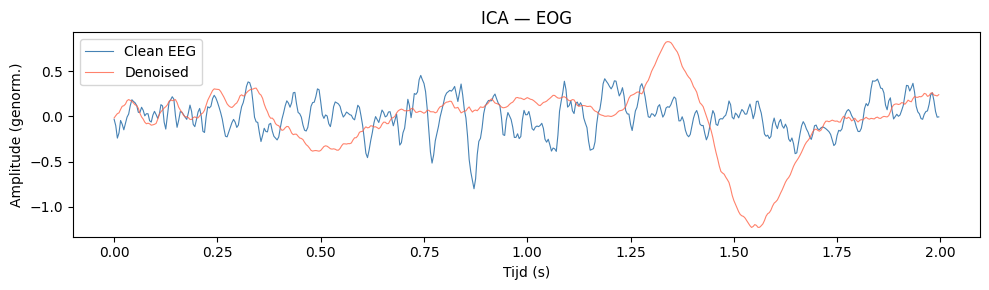

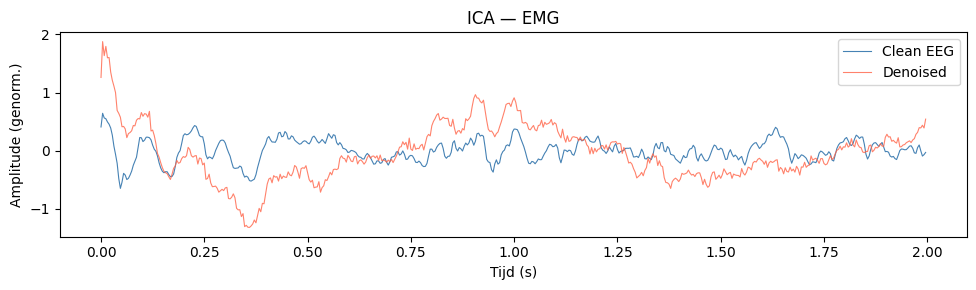

In [26]:
# start optuna hyperparameter tuning 
study_eog = optuna.create_study(direction='minimize')
study_eog.optimize(make_objective(noisy_eog_train, noisy_eog_val, clean_eog_val), n_trials=20)

study_emg = optuna.create_study(direction='minimize')
study_emg.optimize(make_objective(noisy_emg_train, noisy_emg_val, clean_emg_val), n_trials=20)

print("EOG beste params:", study_eog.best_params)
print("EOG beste RRMSE: ", study_eog.best_value)

print("EMG beste params:", study_emg.best_params)
print("EMG beste RRMSE: ", study_emg.best_value)

# train with best hyperparameters and evaluate 
denoised_eog_test, _ = ica_denoise(noisy_eog_train, noisy_eog_test, **study_eog.best_params)
evaluate(clean_eog_test, denoised_eog_test, "EOG")

denoised_emg_test, _ = ica_denoise(noisy_emg_train, noisy_emg_test, **study_emg.best_params)
evaluate(clean_emg_test, denoised_emg_test, "EMG")

# plot the results 
plot_denoising(clean_eog_test, denoised_eog_test, "ICA — EOG")
plot_denoising(clean_emg_test, denoised_emg_test, "ICA — EMG")

### Result

The ICA results are poor for both artifact types. For EOG, the RRMSE of 1.22 
indicates the denoised signal is worse than the original noisy signal (RRMSE > 1), 
and the correlation of 0.13 confirms almost no resemblance to the clean EEG. 
The plot clearly shows the signals diverge significantly.

For EMG, results are slightly better (RRMSE: 0.88, correlation: 0.57), but still 
far from acceptable thresholds (RRMSE < 0.3, correlation > 0.95).

The poor performance is expected: ICA is fundamentally designed for multichannel 
EEG, where it separates sources across electrodes. Applied to single-channel data 
by treating epochs as channels, it cannot properly identify and isolate artifact 
components.

# Denoising data Real-Time